In [4]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("tomekkorbak/python-github-code", split="test")
ds.set_format("pandas")
df = ds[:]

In [ ]:
import sys
sys.path.append("..")

from python_editor.data_filtering import format_df, filter_df

df = format_df(df.copy())
df = filter_df(df.copy())
df


,text,repo_name,path,license,NUM_CHARS
0,from __future__ import print_function\r\n\r\ni...,Jeff-Tian/mybnb,Python27/Lib/test/test___all__.py,apache-2.0,4298
1,from __future__ import print_function\nfrom pa...,dssg/wikienergy,disaggregator/build/pandas/pandas/io/tests/tes...,mit,17790
2,"""""""\nOutlier Detection using Tukeys Filter Cla...",trademob/anna-molly,lib/plugins/tukeys_filter.py,mit,5255
3,# Copyright (c) 2018 PaddlePaddle Authors. A...,PaddlePaddle/Paddle,python/paddle/fluid/tests/unittests/xpu/test_r...,apache-2.0,6221
4,# -*- coding: utf-8 -*-\nfrom __future__ impor...,marevol/gym-starter-kit-example,pong/__init__.py,apache-2.0,240
...,...,...,...,...,...
6270,"""""""\nHere we test our output parsing and match...",PKRoma/httpie,tests/utils/matching/test_matching.py,bsd-3-clause,5827
6271,"from __future__ import absolute_import, unicod...",chrxr/wagtail,wagtail/wagtailsearch/tests/test_db_backend.py,bsd-3-clause,854
6272,from lib.action import BaseVMsAction\n\n__all_...,armab/st2contrib,packs/rackspace/actions/set_vm_metadata_item.py,apache-2.0,490
6273,#\n# Licensed to the Apache Software Foundatio...,practice-vishnoi/dev-spark-1,python/pyspark/mllib/__init__.py,apache-2.0,1208


We use [Pylint](https://pylint.readthedocs.io/en/stable/index.html) to get an initial score of python file quality

In [7]:
import subprocess
import tempfile
from tqdm import tqdm
tqdm.pandas()

def get_pylint_text(row: pd.Series) -> str:
    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".py",
        delete=False
    ) as f:
        f.write(row["text"])
        filename = f.name

    result = subprocess.run(
        ["pylint", filename, "-r", "n", "--output-format=json2"],
        capture_output=True,
        text=True
    )

    return result.stdout

df["pylint_text"] = df.progress_apply(get_pylint_text, axis=1)

100%|██████████| 6275/6275 [1:28:54<00:00,  1.18it/s]  


Examining Pylint output shows that files with "fatal" or "error" messages do not even run and thus get zero score

This is good since we do not want to give a score to a python file that does not even run in the first place

Examining [Pylint messages](https://pylint.readthedocs.io/en/stable/user_guide/messages/messages_overview.html#) more closely shows that all fatal and error messages are legit to consider that the file won't run except [import-error / E0401](https://pylint.readthedocs.io/en/stable/user_guide/messages/error/import-error.html) which would be hard to verify in deployment since it would require creating a venv then downloading the file's dependencies so we will simply ignore it

We do so by running

    pylint --generate-rcfile > .pylintrc

in terminal which would create the config file ".pylintrc" then adding "disabl=E0401" under "[MESSAGES CONTROL]" in that file

In [8]:
import json

sample_pylint_text = json.loads(df["pylint_text"][0])
sample_pylint_text

{'messages': [{'type': 'error',
   'symbol': 'syntax-error',
   'message': "Parsing failed: 'Missing parentheses in call to 'exec'. Did you mean exec(...)? (tmpzumk3u24, line 29)'",
   'messageId': 'E0001',
   'confidence': 'HIGH',
   'module': 'tmpzumk3u24',
   'obj': '',
   'line': 29,
   'column': 17,
   'endLine': None,
   'endColumn': None,
   'path': '/tmp/tmpzumk3u24.py',
   'absolutePath': '/tmp/tmpzumk3u24.py'}],
 'statistics': {'messageTypeCount': {'fatal': 0,
   'error': 1,
   'warning': 0,
   'refactor': 0,
   'convention': 0,
   'info': 0},
  'modulesLinted': 4,
  'score': 0}}

We extract score where files with fatal or error messages get -1 (representing Null) and others get thier Pylint score

In [9]:
def get_pylint_score(row: pd.Series) -> float:
    pylint_json = json.loads(row["pylint_text"])
    fatal = pylint_json["statistics"]["messageTypeCount"]["fatal"]
    error = pylint_json["statistics"]["messageTypeCount"]["error"]

    if fatal or error:
        return -1
    else:
        return pylint_json["statistics"]["score"]

df["pylint_score"] = df.progress_apply(get_pylint_score, axis=1)

100%|██████████| 6275/6275 [00:00<00:00, 11403.47it/s]


We execlude files with fatal or error messages

In [10]:
df = df[df["pylint_score"] != -1]
df

,text,repo_name,path,license,NUM_CHARS,pylint_text,pylint_score
2,"""""""\nOutlier Detection using Tukeys Filter Cla...",trademob/anna-molly,lib/plugins/tukeys_filter.py,mit,5255,"{\n ""messages"": [\n {\n ""...",7.634409
3,# Copyright (c) 2018 PaddlePaddle Authors. A...,PaddlePaddle/Paddle,python/paddle/fluid/tests/unittests/xpu/test_r...,apache-2.0,6221,"{\n ""messages"": [\n {\n ""...",7.037037
4,# -*- coding: utf-8 -*-\nfrom __future__ impor...,marevol/gym-starter-kit-example,pong/__init__.py,apache-2.0,240,"{\n ""messages"": [\n {\n ""...",8.000000
5,import re\n\nfrom tornado.escape import xhtml_...,JmPotato/College,handlers/utils.py,mit,2237,"{\n ""messages"": [\n {\n ""...",7.872340
8,from tests import PMGTestCase\nfrom pmg.models...,Code4SA/pmg-cms-2,tests/unit/test_attendance.py,apache-2.0,6441,"{\n ""messages"": [\n {\n ""...",8.358209
...,...,...,...,...,...,...,...
6267,import time\n\nimport sqlalchemy as SA\n\nimpo...,Yelp/pushmanager,pushmanager/servlets/livepush.py,apache-2.0,3789,"{\n ""messages"": [\n {\n ""...",7.142857
6268,import os\n\nfrom django.core.wsgi import get_...,kaiocesar/easy-bank,easybank/wsgi.py,mit,169,"{\n ""messages"": [\n {\n ""...",7.500000
6269,# Copyright 2017 The TensorFlow Authors. All R...,eadgarchen/tensorflow,tensorflow/python/estimator/util_test.py,apache-2.0,3897,"{\n ""messages"": [\n {\n ""...",0.000000
6272,from lib.action import BaseVMsAction\n\n__all_...,armab/st2contrib,packs/rackspace/actions/set_vm_metadata_item.py,apache-2.0,490,"{\n ""messages"": [\n {\n ""...",6.666667


We see that on average larger the NUM_CHARS larger the score

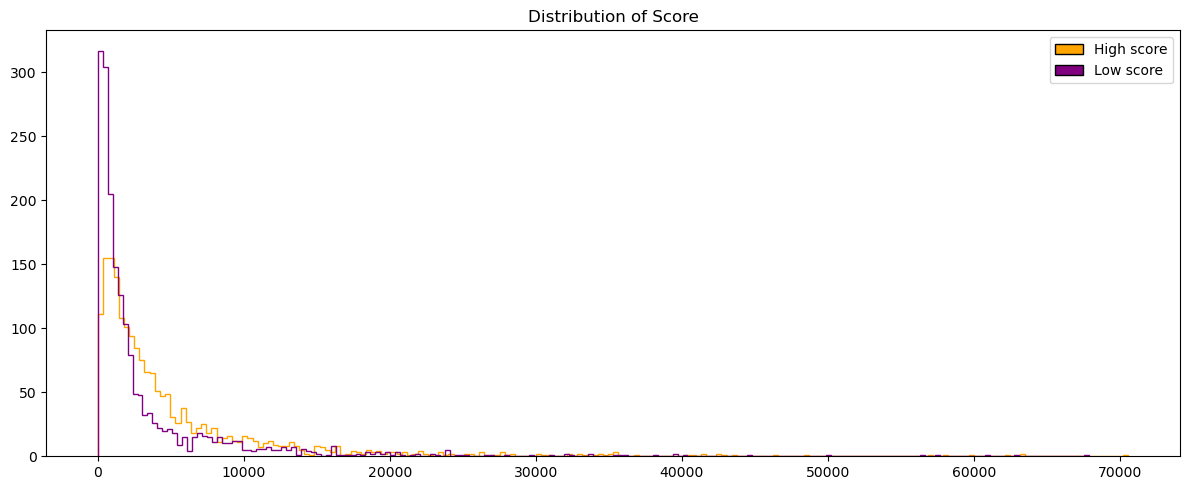

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

high_score = df["pylint_score"] > df["pylint_score"].median()

fig = plt.figure(figsize=(12,5))
plt.hist(df[high_score]["NUM_CHARS"], bins=200, histtype="step", color="orange")
plt.hist(df[~high_score]["NUM_CHARS"], bins=200, histtype="step", color="purple")

plt.title("Distribution of Score")
handles = [Rectangle((0, 0), 1, 1, color=c, ec="k") for c in ["orange", "purple"]]
labels = ["High score", "Low score"]
plt.legend(handles, labels)

plt.tight_layout()
plt.show()

We save the processed df to load it easily later

In [12]:
df.to_csv("../data/exploration.csv", index=False)